Saving german_credit_data.csv to german_credit_data.csv
Dataset Shape: (1000, 10)

First 5 Rows:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Missing Values:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account   

/tmp/ipykernel_6609/2321938413.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Saving accounts'].fillna('unknown', inplace=True)
/tmp/ipykernel_6609/2321938413.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

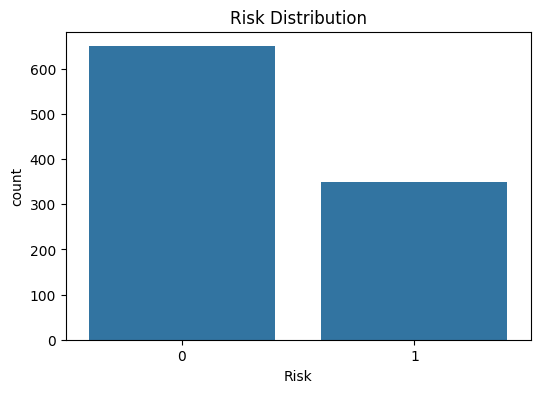

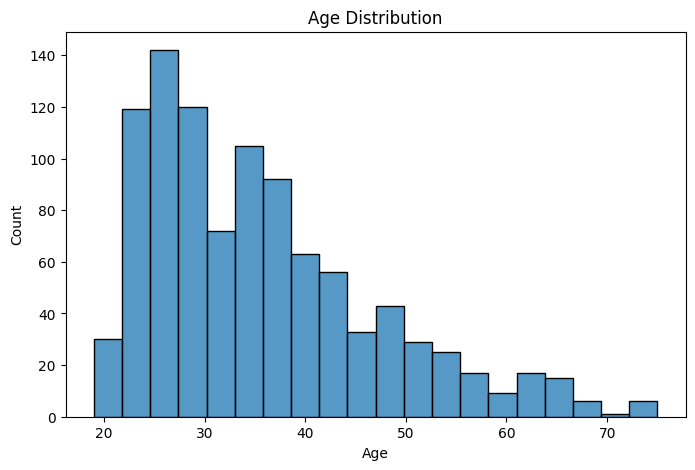

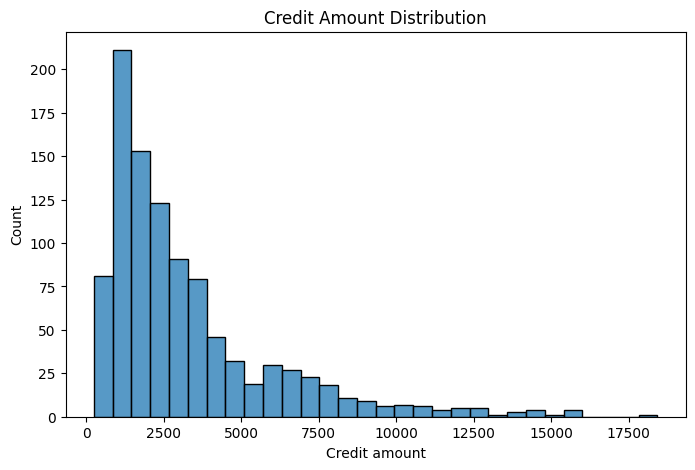

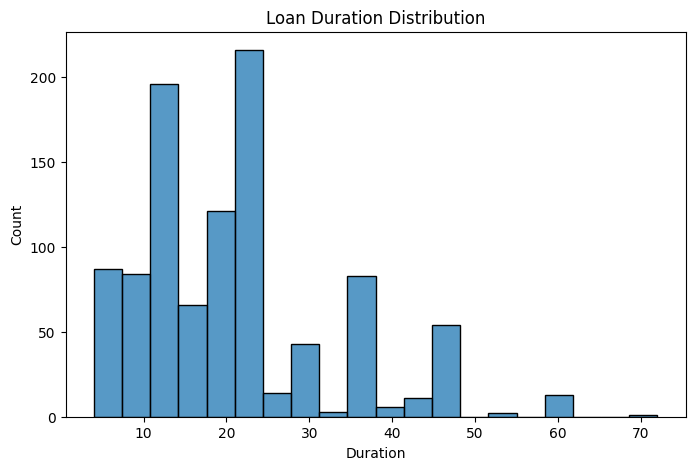

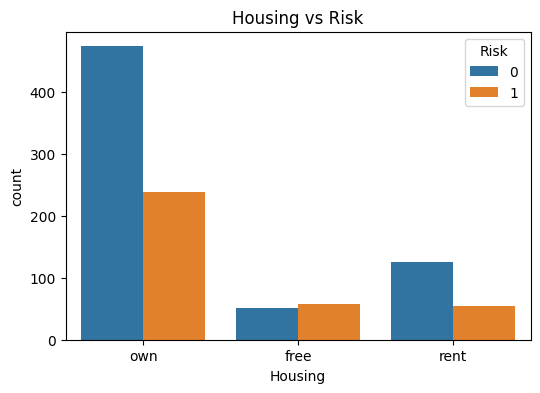

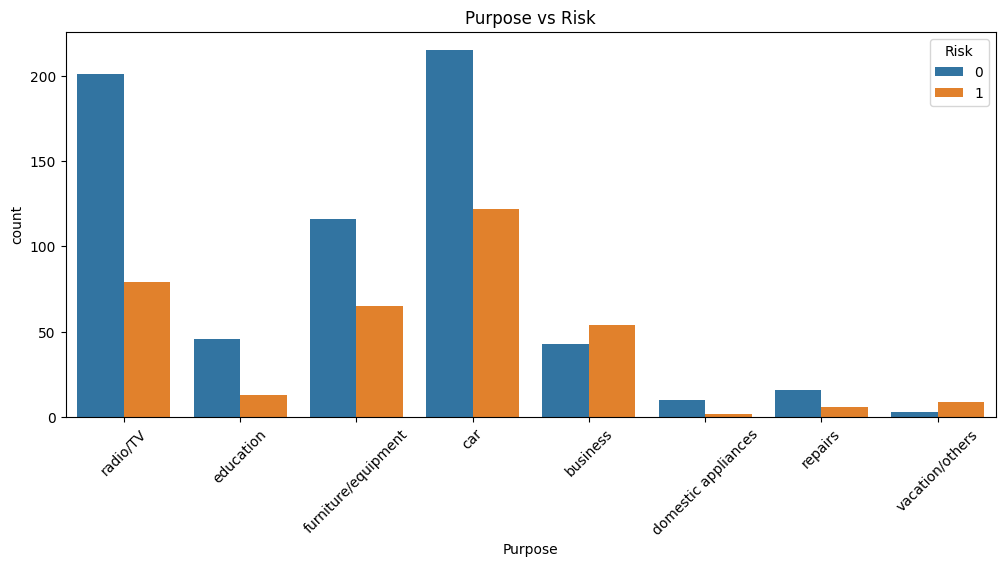

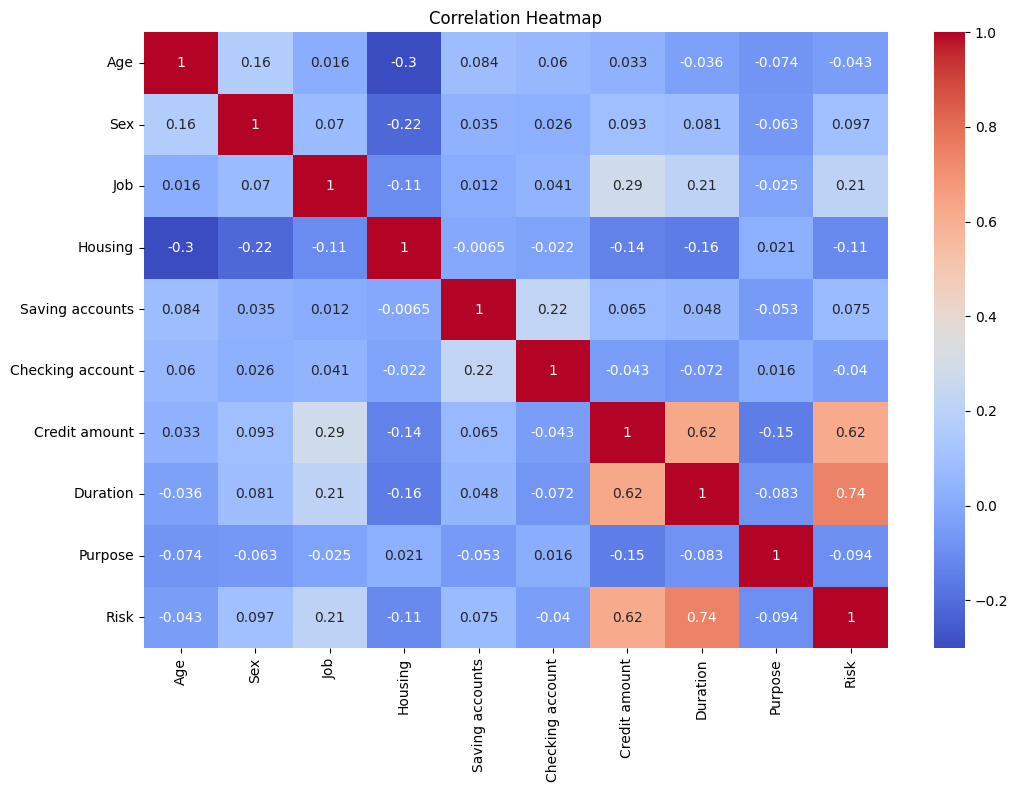


Original Class Distribution:
Risk
0    520
1    280
Name: count, dtype: int64

After SMOTE:
Risk
1    520
0    520
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LOGISTIC REGRESSION RESULTS
Accuracy : 0.925
Recall   : 0.9285714285714286
ROC-AUC  : 0.9764835164835164

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       130
           1       0.87      0.93      0.90        70

    accuracy                           0.93       200
   macro avg       0.91      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



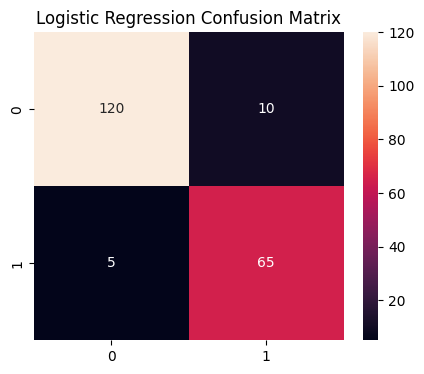


RANDOM FOREST RESULTS
Accuracy : 1.0
Recall   : 1.0
ROC-AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       130
           1       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



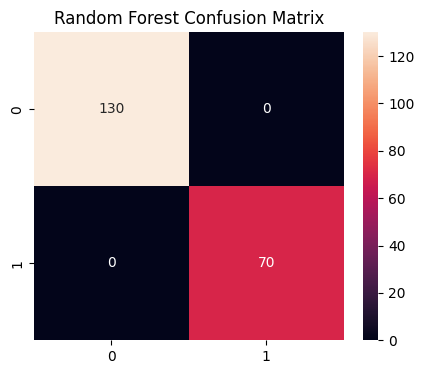


Top 10 Important Features
            Feature  Importance
7          Duration    0.532950
6     Credit amount    0.414509
0               Age    0.014079
3           Housing    0.012399
8           Purpose    0.009685
5  Checking account    0.007040
4   Saving accounts    0.004355
2               Job    0.003713
1               Sex    0.001270


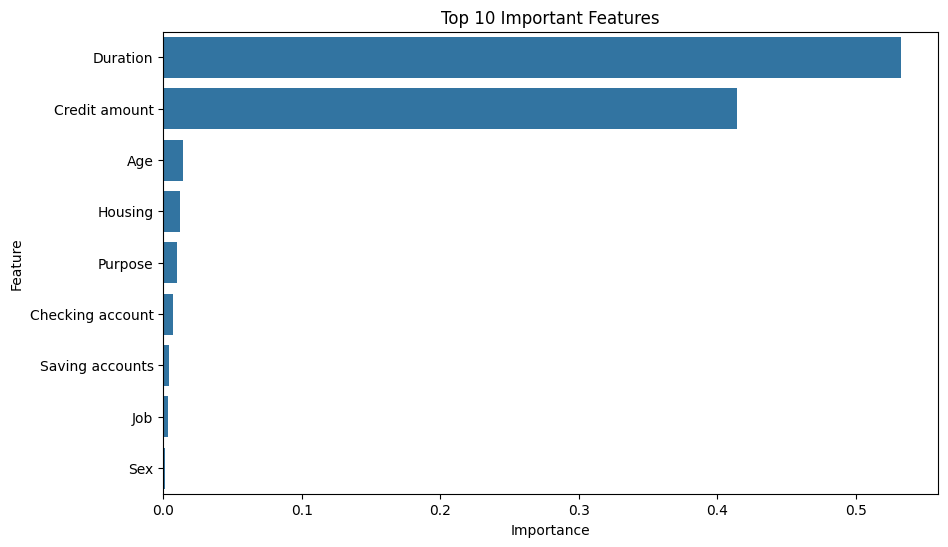

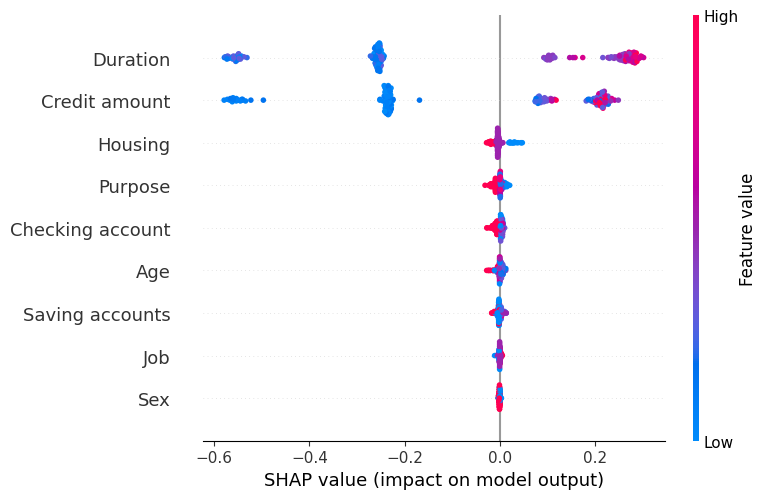


MODEL COMPARISON
                 Model  Accuracy    Recall   ROC-AUC
0  Logistic Regression     0.925  0.928571  0.976484
1        Random Forest     1.000  1.000000  1.000000

FINAL CONCLUSION

1. Loaded and cleaned German Credit dataset.

2. Handled missing values in:
   - Saving accounts
   - Checking account

3. Created Risk target variable using:
   - Credit Amount
   - Duration

4. Performed Exploratory Data Analysis (EDA).

5. Encoded categorical variables.

6. Applied SMOTE to handle class imbalance.

7. Built:
   - Logistic Regression
   - Random Forest

8. Evaluated models using:
   - Accuracy
   - Recall
   - ROC-AUC
   - Confusion Matrix

9. Used SHAP Explainability for feature interpretation.

10. Key factors affecting risk:
    - Credit Amount
    - Duration
    - Checking Account
    - Saving Account
    - Age

11. Random Forest generally performs better
    than Logistic Regression for this dataset.



In [1]:
# ============================================================
# CREDIT RISK MODELING PROJECT - COMPLETE GOOGLE COLAB CODE
# ============================================================

# Install Required Libraries
!pip install imbalanced-learn shap -q

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

# ============================================================
# UPLOAD DATASET
# ============================================================

uploaded = files.upload()

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("german_credit_data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# DATA CLEANING
# ============================================================

# Remove index column if present
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Fill Missing Values
df['Saving accounts'].fillna('unknown', inplace=True)
df['Checking account'].fillna('unknown', inplace=True)

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# CREATE RISK TARGET VARIABLE
# ============================================================

credit_threshold = df["Credit amount"].median()
duration_threshold = df["Duration"].median()

df["Risk"] = np.where(
    (df["Credit amount"] > credit_threshold) &
    (df["Duration"] > duration_threshold),
    1,
    0
)

print("\nRisk Distribution:")
print(df["Risk"].value_counts())

# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

# Risk Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)
plt.title("Risk Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

# Credit Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Credit amount"], bins=30)
plt.title("Credit Amount Distribution")
plt.show()

# Duration Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Duration"], bins=20)
plt.title("Loan Duration Distribution")
plt.show()

# Housing vs Risk
plt.figure(figsize=(6,4))
sns.countplot(x="Housing", hue="Risk", data=df)
plt.title("Housing vs Risk")
plt.show()

# Purpose vs Risk
plt.figure(figsize=(12,5))
sns.countplot(x="Purpose", hue="Risk", data=df)
plt.xticks(rotation=45)
plt.title("Purpose vs Risk")
plt.show()

# ============================================================
# LABEL ENCODING
# ============================================================

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop("Risk", axis=1)
y = df["Risk"]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nOriginal Class Distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# ============================================================
# LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ============================================================
# RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print("\nMODEL COMPARISON")
print(results)

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "="*60)
print("FINAL CONCLUSION")
print("="*60)

print("""
1. Loaded and cleaned German Credit dataset.

2. Handled missing values in:
   - Saving accounts
   - Checking account

3. Created Risk target variable using:
   - Credit Amount
   - Duration

4. Performed Exploratory Data Analysis (EDA).

5. Encoded categorical variables.

6. Applied SMOTE to handle class imbalance.

7. Built:
   - Logistic Regression
   - Random Forest

8. Evaluated models using:
   - Accuracy
   - Recall
   - ROC-AUC
   - Confusion Matrix

9. Used SHAP Explainability for feature interpretation.

10. Key factors affecting risk:
    - Credit Amount
    - Duration
    - Checking Account
    - Saving Account
    - Age

11. Random Forest generally performs better
    than Logistic Regression for this dataset.
""")